### 와인 데이터 딥러닝으로 분류
202435119 한여원

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

In [ ]:
# 202435119 한여원
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("D:\hanyeowon\Coding\pythonworks\deep\data\wine.csv")
# print(df)
y = df["Wine"]
y = pd.get_dummies(y).values
X = df.drop("Wine", axis=1)
print(X.dtypes)
X = X.values
print(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Alcohol                 float64
Malic.acid              float64
Ash                     float64
Acl                     float64
Mg                        int64
Phenols                 float64
Flavanoids              float64
Nonflavanoid.phenols    float64
Proanth                 float64
Color.int               float64
Hue                     float64
OD                      float64
Proline                   int64
dtype: object
[[ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ True False False]
 [ 

<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:4: SyntaxWarning: invalid escape sequence '\h'
C:\Users\gram\AppData\Local\Temp\ipykernel_8632\2933415785.py:4: SyntaxWarning: invalid escape sequence '\h'
  df = pd.read_csv("D:\hanyeowon\Coding\pythonworks\deep\data\wine.csv")


Epoch 1/50


d:\hanyeowon\Coding\pythonworks\deep\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.4717 - loss: 1.1034 - val_accuracy: 0.5926 - val_loss: 0.9331
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6604 - loss: 0.8288 - val_accuracy: 0.8148 - val_loss: 0.7449
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8585 - loss: 0.6637 - val_accuracy: 0.9259 - val_loss: 0.5938
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9057 - loss: 0.5225 - val_accuracy: 0.9259 - val_loss: 0.4739
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9245 - loss: 0.4201 - val_accuracy: 0.9630 - val_loss: 0.3750
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9717 - loss: 0.3373 - val_accuracy: 0.9630 - val_loss: 0.2979
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9717 - loss: 0.2665 - val_accuracy: 0.9630 - val_loss: 0.2405
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9434 - loss: 0.2406 - val_accuracy: 0.9630 - val_loss: 0.1999
Epoch 9/50


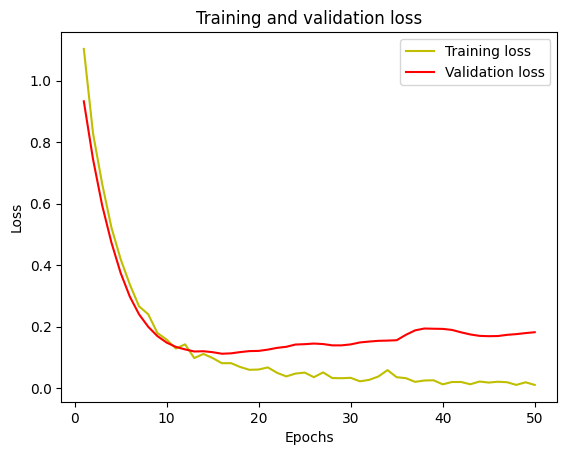

In [ ]:
model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X.shape[1], )),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dense(y.shape[1], activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

y_pred = model.predict(X_test_scaled)

y_test_class = np.argmax(y_test, axis=1)
y_pred_class = np.argmax(y_pred, axis=1)

loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
import matplotlib.pyplot as plt

epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
print(loss)
print(val_loss)
print(acc)

[1.103408932685852, 0.8288309574127197, 0.6636608839035034, 0.5225455164909363, 0.42008867859840393, 0.33731603622436523, 0.2665073871612549, 0.2405526489019394, 0.17949071526527405, 0.1582544445991516, 0.12920646369457245, 0.14288698136806488, 0.09812355041503906, 0.11164171993732452, 0.09823042154312134, 0.0815238356590271, 0.0815928652882576, 0.06907644122838974, 0.05995247885584831, 0.060981594026088715, 0.06780286133289337, 0.05018622800707817, 0.03858046606183052, 0.04775853082537651, 0.0509379506111145, 0.036029230803251266, 0.05162137374281883, 0.03321829065680504, 0.03269285336136818, 0.03391241282224655, 0.022639498114585876, 0.027225712314248085, 0.038179848343133926, 0.059000007808208466, 0.03593175485730171, 0.03280464932322502, 0.020846767351031303, 0.025185804814100266, 0.026013707742094994, 0.012781854718923569, 0.020288608968257904, 0.020433718338608742, 0.012975913472473621, 0.02193426713347435, 0.018487093970179558, 0.021214254200458527, 0.01957913674414158, 0.010902

In [12]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test_class,y_pred_class))
print(confusion_matrix(y_test_class,y_pred_class))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        16
           1       0.95      1.00      0.98        21
           2       1.00      1.00      1.00         8

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45

[[15  1  0]
 [ 0 21  0]
 [ 0  0  8]]
